# Week 03 · Formulación y búsqueda no informada
### Salazar · Ochoa · Chano
**CMP-4004 — Inteligencia Artificial**

Nuestra pregunta: **¿qué cambia cuando mantenemos el problema y modificamos el orden de búsqueda?**

Presentamos tres resultados: una formulación segura de misioneros y caníbales, cuatro algoritmos que respetan la interfaz del curso y una comparación sobre 40 instancias del 8-puzzle.

**Recorrido:** formulación → código → demostraciones → pruebas → medición → conclusiones.

Este notebook ejecuta `starter.py`; no contiene otra implementación de los algoritmos. El material original en inglés está conservado en `referencias/`. La asistencia utilizada está documentada en `AI_LOG.md`.

## 1. Preparación y archivos que presentamos

Abrimos este notebook desde la carpeta de entrega y ejecutamos las celdas en orden. Las salidas guardadas corresponden a una ejecución completa.

| Archivo | Papel en el trabajo |
|---|---|
| `starter.py` | Nuestra formulación, BFS, DFS, UCS, búsqueda limitada, IDS y medición |
| `search.py` | Motor e interfaz del profesor, conservados sin cambios |
| `test_search.py` | Los cinco tests originales, conservados sin cambios |
| `instances.json` | Banco original, conservado sin cambios |
| `experiments.py` | Guarda las mediciones y genera la gráfica |
| `resultados/` | Datos de las 160 corridas, resumen y gráfica |

**Al exponer:** primero ubicamos el código; después explicamos sus decisiones con ejemplos ejecutables.

In [1]:
from pathlib import Path
import sys, json, inspect, importlib, csv, math, html
from statistics import mean
from IPython.display import display, HTML, Markdown

ROOT = Path.cwd()
assert (ROOT / 'starter.py').exists(), 'Abrir el notebook desde la carpeta de entrega.'
import starter as s
import experiments as ex
from search import Problem, Node, TinyGraph, EightPuzzle, D8, GOAL, load_instances
importlib.reload(s)
importlib.reload(ex)

def tabla(headers, rows):
    def fmt(value):
        return f'{value:,.2f}' if isinstance(value, float) else str(value)
    head = ''.join(f'<th>{html.escape(str(h))}</th>' for h in headers)
    body = ''.join('<tr>' + ''.join(f'<td>{html.escape(fmt(v))}</td>' for v in row) + '</tr>' for row in rows)
    display(HTML('<table><thead><tr>' + head + '</tr></thead><tbody>' + body + '</tbody></table>'))

print('Equipo: Salazar, Ochoa y Chano')
print('Python:', sys.version.split()[0])
print('Implementación importada:', Path(s.__file__).name)

Equipo: Salazar, Ochoa y Chano
Python: 3.13.14
Implementación importada: starter.py


## 2. De la week 02 a la week 03

En Vacuum World estudiamos agentes que eligen una acción a partir de sus perceptos. Aquí damos el siguiente paso: **formulamos una meta y buscamos una secuencia completa antes de ejecutarla**.

Para estos problemas asumimos un ambiente observable, determinista, discreto y estático. No necesitamos un modelo de lenguaje como competidor: el studio de esta semana pide comparar búsquedas clásicas.

### Los cinco componentes de nuestra formulación

| Componente | Decisión concreta |
|---|---|
| Estado inicial | `(3, 3, 0)`: tres misioneros y tres caníbales a la izquierda, bote a la izquierda |
| Acciones | Cargas `(m, c)` de una o dos personas, disponibles donde está el bote y seguras en ambas orillas |
| Transición | Restamos la carga al salir de la izquierda; la sumamos al regresar; cambiamos el lado del bote |
| Meta | `(0, 0, 1)`: todos a la derecha, incluido el bote |
| Costo | Un cruce cuesta 1, heredado de `Problem.step_cost` |

La derecha se obtiene como `(3-m, 3-c)`. Guardar ambas orillas duplicaría información y permitiría inconsistencias. La tupla es inmutable y se puede guardar en un conjunto.

In [2]:
print(inspect.getsource(s.MissionariesAndCannibals))

class MissionariesAndCannibals(Problem):
    # Orden fijo: facilita reproducir la misma solución en cada ejecución.
    LOADS = ((1, 0), (0, 1), (2, 0), (0, 2), (1, 1))

    def __init__(self):
        super().__init__((3, 3, 0), (0, 0, 1))

    @staticmethod
    def is_valid(state):
        """Verificamos cantidades y seguridad en AMBAS orillas."""
        m, c, boat = state
        return (0 <= m <= 3 and 0 <= c <= 3 and boat in (0, 1)
                and (m == 0 or m >= c)
                and (3 - m == 0 or 3 - m >= 3 - c))

    def actions(self, state):
        # La búsqueda recibe únicamente acciones legales; result transforma.
        if not self.is_valid(state):
            return []
        m, c, boat = state
        available_m, available_c = (m, c) if boat == 0 else (3 - m, 3 - c)
        return [load for load in self.LOADS
                if load[0] <= available_m and load[1] <= available_c
                and self.is_valid(self.result(state, load))]

    def result(self, st

## 3. ¿Dónde rechazamos los cruces ilegales?

Elegimos **`actions()`**. Primero comprobamos disponibilidad de pasajeros; luego calculamos el destino y comprobamos seguridad. Así el motor solo genera sucesores legales.

`result()` aplica la transición con la precondición de recibir una acción legal. Separar transición y filtro evita repetir las mismas verificaciones cada vez que el motor aplica una acción ya validada.

La regla de seguridad es **`m == 0 or m >= c`**, en cada orilla. Una orilla con solo caníbales es válida porque allí no hay misioneros en peligro.

**Ejemplo que defenderemos:** desde `(3,3,0)`, enviar un misionero deja `(2,3,1)`. Aunque la orilla de llegada sea segura, la de salida no lo es. Enviar dos misioneros también es inválido. En cambio, un caníbal, dos caníbales o una pareja sí son cruces legales.

In [3]:
p = s.MissionariesAndCannibals()
tabla(['Carga (M,C)', 'Estado tras el cruce', '¿Legal desde el inicio?'],
      [(load, p.result(p.initial, load), load in p.actions(p.initial)) for load in p.LOADS])
assert set(p.actions(p.initial)) == {(0, 1), (0, 2), (1, 1)}
print('Caso donde falla la derecha:', (2, 1, 1), 'válido =', p.is_valid((2, 1, 1)))

"Carga (M,C)",Estado tras el cruce,¿Legal desde el inicio?
"(1, 0)","(2, 3, 1)",False
"(0, 1)","(3, 2, 1)",True
"(2, 0)","(1, 3, 1)",False
"(0, 2)","(3, 1, 1)",True
"(1, 1)","(2, 2, 1)",True


Caso donde falla la derecha: (2, 1, 1) válido = False


## 4. Solución de misioneros y caníbales, cruce por cruce

Usamos BFS porque todos los cruces cuestan uno. Su garantía de menor número de pasos coincide aquí con menor costo.

En la tabla verificamos cada acción contra `actions()` y comprobamos que los estados resultantes sean seguros. **Llegar a la meta no basta si algún cruce intermedio viola las reglas.**

In [4]:
goal, expanded = s.bfs(p)
state = p.initial
route = [(0, 'Inicio', '—', (3, 3), (0, 0), 'Izquierda')]
for step, load in enumerate(goal.path(), 1):
    assert load in p.actions(state)
    direction = 'Izquierda → derecha' if state[2] == 0 else 'Derecha → izquierda'
    state = p.result(state, load)
    assert p.is_valid(state)
    route.append((step, direction, load, state[:2], (3-state[0], 3-state[1]),
                  'Izquierda' if state[2] == 0 else 'Derecha'))
assert p.is_goal(state)
tabla(['Cruce', 'Dirección', 'Carga (M,C)', 'Izquierda (M,C)', 'Derecha (M,C)', 'Bote'], route)
print(f'Solución: {len(goal.path())} cruces; costo = {goal.g}; expansiones = {expanded}.')

Cruce,Dirección,"Carga (M,C)","Izquierda (M,C)","Derecha (M,C)",Bote
0,Inicio,—,"(3, 3)","(0, 0)",Izquierda
1,Izquierda → derecha,"(0, 2)","(3, 1)","(0, 2)",Derecha
2,Derecha → izquierda,"(0, 1)","(3, 2)","(0, 1)",Izquierda
3,Izquierda → derecha,"(0, 2)","(3, 0)","(0, 3)",Derecha
4,Derecha → izquierda,"(0, 1)","(3, 1)","(0, 2)",Izquierda
5,Izquierda → derecha,"(2, 0)","(1, 1)","(2, 2)",Derecha
6,Derecha → izquierda,"(1, 1)","(2, 2)","(1, 1)",Izquierda
7,Izquierda → derecha,"(2, 0)","(0, 2)","(3, 1)",Derecha
8,Derecha → izquierda,"(0, 1)","(0, 3)","(3, 0)",Izquierda
9,Izquierda → derecha,"(0, 2)","(0, 1)","(3, 2)",Derecha


Solución: 11 cruces; costo = 11; expansiones = 14.


## 5. Una función de búsqueda, tres fronteras

| Algoritmo | Frontera | Próximo nodo | Qué podemos afirmar |
|---|---|---|---|
| BFS | FIFO | El que entró primero | Menor cantidad de acciones; menor costo si los costos son uniformes |
| DFS | LIFO | El que entró al final | Encuentra una solución en este grafo finito con control de repetidos; no asegura calidad |
| UCS | Prioridad por `g` | El de menor costo acumulado | Costo óptimo con costos no negativos en estos grafos finitos |

Las tres funciones son cortas deliberadamente: **el profesor ya entregó el ciclo de búsqueda**. Reescribirlo triplicaría código sin aportar una estrategia distinta.

Para completitud en espacios infinitos hacen falta condiciones adicionales: ramificación finita y, en UCS, un costo mínimo positivo evitan explorar indefinidamente por debajo del costo de la solución.

In [5]:
for algorithm in [s.bfs, s.dfs, s.ucs]:
    print(inspect.getsource(algorithm))

def bfs(problem):
    """Breadth-first search. Complete; optimal only when step costs are uniform."""
    return search(problem, "fifo")

def dfs(problem):
    """Depth-first (graph) search. The explored set is what makes it terminate on
    cyclic graphs -- do not remove it. Not optimal."""
    return search(problem, "lifo")

def ucs(problem):
    """Uniform-cost search. Optimal for any non-negative step costs."""
    return search(problem, "priority")



## 6. Menos pasos no significa menor costo

Usamos `TinyGraph`, entregado por el profesor:

```text
start ──10──▶ A (meta)
  └──1──▶ B ──1──▶ A
```

BFS saca `A` primero porque está a una acción. UCS saca `B` con costo 1 y luego la nueva ruta a `A` con costo 2.

**¿Por qué probamos la meta al extraer de la frontera?** Al generar la primera `A`, todavía no sabemos si existe una ruta más barata. En UCS, el orden por costo justifica aceptar la meta cuando sale de la cola. Esto no convierte a BFS en óptimo con costos distintos.

In [6]:
comparison = []
for name, algorithm in [('BFS', s.bfs), ('DFS', s.dfs), ('UCS', s.ucs), ('IDS', s.ids)]:
    node, exp = algorithm(TinyGraph('start', 'A'))
    comparison.append((name, ['start'] + node.path(), len(node.path()), node.g, exp))
tabla(['Algoritmo', 'Ruta', 'Acciones', 'Costo', 'Expansiones'], comparison)
assert comparison[0][3] == 10 and comparison[2][3] == 2

Algoritmo,Ruta,Acciones,Costo,Expansiones
BFS,"['start', 'A']",1,10,1
DFS,"['start', 'B', 'A']",2,2,2
UCS,"['start', 'B', 'A']",2,2,2
IDS,"['start', 'A']",1,10,1


## 7. IDS: profundidad limitada y reinicio

`depth_limited(problem, limit)` devuelve **`(node, expansions, hit_limit)`**. El indicador distingue un corte por profundidad de una búsqueda agotada.

1. Revisamos la meta antes del límite: una meta exactamente en el nivel límite sí cuenta.
2. Conservamos `on_path`, el conjunto de estados del camino actual. Al regresar de una rama, retiramos su estado.
3. No usamos un conjunto global: un estado visto por una ruta larga puede ser necesario después por otra más corta.
4. IDS prueba límites `0, 1, 2, ...` y suma el trabajo de todos los intentos.

Al alcanzar el límite inspeccionamos si queda algún sucesor fuera del camino, sin descender. Una hoja realmente agotada devuelve `hit_limit=False`.

**Límite práctico:** `max_depth=40` es el valor del profesor. Si se alcanza, `None` no demuestra que el problema sea imposible; puede significar que falta profundidad.

In [7]:
print(inspect.getsource(s.depth_limited))
print(inspect.getsource(s.ids))

def depth_limited(problem, limit):
    """Recursive tree search to a fixed depth.

    Return (node, expansions, hit_limit): ``node`` is the goal Node or None;
    ``expansions`` counts expanded nodes; ``hit_limit`` is True iff the search was
    cut off by the depth limit (as opposed to exhausting the subtree). The
    hit_limit flag is what lets ids() know whether deepening further can help.

    Hint: skip the immediate parent state to avoid trivial 2-cycles at no memory
    cost, then recurse with limit-1.
    """
    if not isinstance(limit, int) or limit < 0:
        raise ValueError("limit debe ser un entero no negativo")
    expansions = 0
    on_path = {problem.initial}

    def visit(node, remaining):
        nonlocal expansions
        if problem.is_goal(node.state):
            return node, False
        if remaining == 0:
            # Un límite en una hoja agotada no es un corte real.
            # Inspeccionar sucesores aquí no se cuenta como expandir:
            # no c

In [8]:
trace = []
for limit in range(9):
    node, exp, cutoff = s.depth_limited(EightPuzzle(D8), limit)
    trace.append((limit, node is not None, exp, cutoff))
tabla(['Límite', '¿Encontró meta?', 'Expansiones del intento', '¿Hubo corte?'], trace)
node, total = s.ids(EightPuzzle(D8))
assert total == sum(row[2] for row in trace)
print(f'IDS: {len(node.path())} movimientos; {total} expansiones acumuladas.')

Límite,¿Encontró meta?,Expansiones del intento,¿Hubo corte?
0,False,0,True
1,False,1,True
2,False,3,True
3,False,7,True
4,False,15,True
5,False,31,True
6,False,51,True
7,False,91,True
8,True,34,False


IDS: 8 movimientos; 233 expansiones acumuladas.


### Qué cuenta una expansión y qué memoria estamos usando

En `search.py`, el contador aumenta cuando un estado no visitado sale de la frontera y se procesan sus acciones; la meta no suma. En nuestra búsqueda limitada tampoco contamos la meta ni los nodos cortados sin descender. La inspección del límite sí tiene costo de CPU aunque no incremente el contador.

IDS puede expandir el mismo estado en ramas e iteraciones diferentes; eso es trabajo real y lo sumamos. Por eso expansiones **no equivale a estados únicos, tiempo exacto ni memoria medida**.

La cota habitual de memoria de DFS de árbol es `O(bm)`, pero el DFS entregado es de **grafo** y conserva `explored`, que puede ocupar `O(|V|)`. Nuestro IDS guarda el camino y la pila recursiva, sin un historial global; conserva la cota `O(bd)` habitual. No medimos memoria en bytes.

## 8. Pruebas antes de interpretar resultados

Ejecutamos los cinco tests originales sin modificarlos y seis pruebas adicionales del grupo. Las adicionales verifican cruces legales, los 11 viajes, agotamiento frente a corte, revisita por una ruta más corta y límites de profundidad.

El test que exige costo 10 a BFS **debe pasar**: demuestra el límite de su garantía, no un error que debamos ocultar.

In [9]:
import subprocess
for script in ['test_search.py', 'test_group.py']:
    result = subprocess.run([sys.executable, script], cwd=ROOT, capture_output=True, text=True)
    print(f'--- {script} ---')
    print(result.stdout + result.stderr)
    assert result.returncode == 0

--- test_search.py ---
  ok  bfs optimal on uniform costs (len=8)
  ok  bfs suboptimal on non-uniform costs (g=10 > optimum 2 -- the lesson)
  ok  dfs terminates on a cyclic graph (explored set does its job)
  ok  ucs optimal on non-uniform costs (g=2)
  ok  ids matches bfs solution length (8) at O(bd) memory

all 5 tests pass



--- test_group.py ---
test_all_legal_crossings (__main__.GroupTests.test_all_legal_crossings) ... ok
test_cutoff_and_exhaustion (__main__.GroupTests.test_cutoff_and_exhaustion) ... ok
test_empty_bank (__main__.GroupTests.test_empty_bank) ... ok
test_initial_goal_and_depth_boundary (__main__.GroupTests.test_initial_goal_and_depth_boundary) ... ok
test_missionaries_solution (__main__.GroupTests.test_missionaries_solution) ... ok
test_revisit_via_shorter_path (__main__.GroupTests.test_revisit_via_shorter_path) ... ok

----------------------------------------------------------------------
Ran 6 tests in 0.003s

OK



## 9. El 8-puzzle: demostración visible de una solución

Mantenemos la representación del profesor: una tupla de nueve posiciones y `0` para el hueco. Una acción es el índice con el que intercambiamos el hueco; no el valor de la ficha.

Mostramos una instancia de ocho movimientos para comprobar visualmente que la ruta reconstruida sí llega al tablero objetivo.

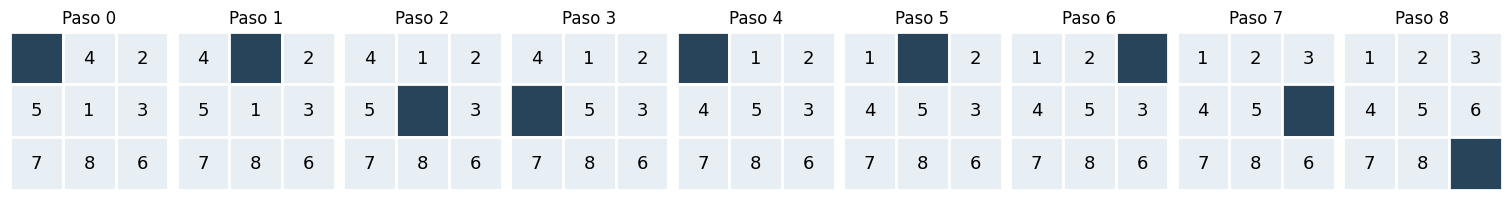

In [10]:
import matplotlib.pyplot as plt
problem = EightPuzzle(D8)
node, exp = s.bfs(problem)
states = [problem.initial]
for action in node.path():
    assert action in problem.actions(states[-1])
    states.append(problem.result(states[-1], action))
assert states[-1] == GOAL
fig, axes = plt.subplots(1, len(states), figsize=(15, 2.1), layout='constrained')
for step, (ax, state) in enumerate(zip(axes, states)):
    ax.set(xlim=(0,3), ylim=(3,0), aspect='equal', title=f'Paso {step}')
    for i, value in enumerate(state):
        x, y = i % 3, i // 3
        ax.add_patch(plt.Rectangle((x,y),1,1, facecolor='#e7eff5' if value else '#27445b', edgecolor='white', linewidth=2))
        if value: ax.text(x+.5,y+.5,str(value),ha='center',va='center',fontsize=13)
    ax.axis('off')
plt.show()

## 10. Diseño del experimento

Usamos las **40 instancias originales**: diez por profundidad óptima 4, 8, 12 y 16. Corremos los cuatro algoritmos sobre cada una: **160 corridas**, con el mismo orden de acciones y sin modificar el banco.

Guardamos expansiones y longitud de solución por instancia. La media resume cada grupo, pero mostramos también mediana, mínimo y máximo porque DFS puede variar mucho.

`REPETIR_MEDICION=False` carga la corrida guardada y comprueba huellas del código, banco y CSV. Para recalcular todo, cambiamos a `True` o ejecutamos `python experiments.py`. Cargar resultados no se presenta como una medición nueva.

El tiempo guardado es el total de las 160 búsquedas, no una comparación de latencia por algoritmo.

In [11]:
print(inspect.getsource(s.measure))

def measure(bank=None):
    """Run all four on the 8-puzzle bank and return rows of
    (depth, algorithm, expansions, solution_length). Then plot expansions vs.
    depth on a LOG y-axis -- that log-scale plot is the deliverable."""
    from search import load_instances, EightPuzzle
    bank = load_instances() if bank is None else bank
    rows = []
    for depth in sorted(bank):
        for state in bank[depth]:
            p = EightPuzzle(state)
            for name, algo in [("BFS", bfs), ("DFS", dfs),
                               ("UCS", ucs), ("IDS", ids)]:
                node, exp = algo(p)
                if node is None:
                    raise RuntimeError(f"{name} no resolvió la instancia de profundidad {depth}")
                rows.append((depth, name, exp, len(node.path())))
    return rows



In [12]:
REPETIR_MEDICION = False
rows = ex.run() if REPETIR_MEDICION else ex.load()
summary = ex.summarize(rows)
metadata = json.loads((ROOT / 'resultados/metadata.json').read_text())
print('Modo:', 'medición nueva' if REPETIR_MEDICION else 'lectura de corrida verificada')
print('Corridas:', len(rows), '| Fecha UTC:', metadata['utc'])
print('Tiempo total registrado (s):', round(metadata['seconds_total'], 2))
assert len(rows) == 160
assert all(r['solution_length'] == r['depth'] for r in rows if r['algorithm'] != 'DFS')
tabla(['Profundidad', 'Algoritmo', 'n', 'Exp. media', 'Exp. mediana', 'Exp. mín.', 'Exp. máx.', 'Long. media', 'Long. mín.', 'Long. máx.'],
      [(r['depth'],r['algorithm'],r['n'],r['expansions_mean'],r['expansions_median'],
        r['expansions_min'],r['expansions_max'],r['length_mean'],r['length_min'],r['length_max']) for r in summary])

Modo: lectura de corrida verificada
Corridas: 160 | Fecha UTC: 2026-09-09T18:29:58.852732+00:00
Tiempo total registrado (s): 7.92


Profundidad,Algoritmo,n,Exp. media,Exp. mediana,Exp. mín.,Exp. máx.,Long. media,Long. mín.,Long. máx.
4,BFS,10,25.20,27.00,20,28,4,4,4
4,DFS,10,"12,489.30",276.00,10,122569,"9,646.80",10,94144
4,UCS,10,25.20,27.00,20,28,4,4,4
4,IDS,10,22.90,24.00,18,30,4,4,4
8,BFS,10,238.50,227.00,172,328,8,8,8
8,DFS,10,"37,578.40","35,984.00",24,128085,"33,406.20",24,94280
8,UCS,10,238.50,227.00,172,328,8,8,8
8,IDS,10,329.60,301.50,233,476,8,8,8
12,BFS,10,"1,506.80","1,398.50",1160,2177,12,12,12
12,DFS,10,"37,701.40","33,556.50",6000,78941,"36,378.40",5944,73532


In [13]:
verification = json.loads((ROOT / 'resultados/verification.json').read_text())
assert verification['fingerprints'] == ex.fingerprints()
tabla(['Comprobación independiente', 'Resultado'], [
    ('Estados alcanzables recorridos por BFS', verification['reachable_states']),
    ('Profundidades del banco verificadas', verification['bank_depths_verified']),
    ('Rutas completas reproducidas', verification['routes_verified']),
    ('Movimientos legales reproducidos', verification['legal_moves_replayed'])])

Comprobación independiente,Resultado
Estados alcanzables recorridos por BFS,181440
Profundidades del banco verificadas,40
Rutas completas reproducidas,160
Movimientos legales reproducidos,1096882


## 11. Gráfica de escalamiento — entregable principal

El eje vertical es logarítmico: subir una distancia igual representa multiplicar expansiones por un mismo factor. Las líneas muestran medias y los puntos transparentes las diez corridas.

BFS y UCS se superponen: con costo unitario, ordenar por `g` equivale a ordenar por profundidad; el desempate estable del motor mantiene su orden. El crecimiento aproximadamente recto en esta escala sugiere crecimiento exponencial **en el intervalo medido**. No lo asumimos para DFS ni para profundidades arbitrarias.

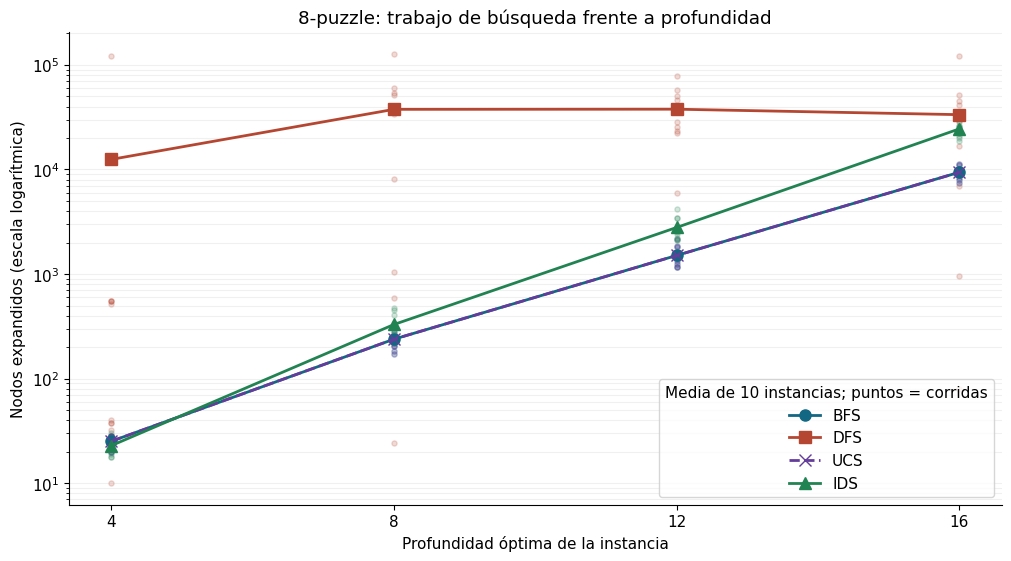

In [14]:
fig = ex.plot(rows)
plt.show()

## 12. Qué dicen nuestros datos

No elegimos un ganador solo por llegar a la meta: comparamos calidad y trabajo.

Calculamos la relación IDS/BFS con las medias de cada profundidad. El ejemplo teórico del 11 % para un árbol con ramificación 10 **no predice** la relación de este grafo con estados repetidos y parada al encontrar la meta.

In [15]:
ratios = []
for depth in [4,8,12,16]:
    b = next(r for r in summary if r['depth']==depth and r['algorithm']=='BFS')
    i = next(r for r in summary if r['depth']==depth and r['algorithm']=='IDS')
    ratios.append((depth, b['expansions_mean'], i['expansions_mean'], i['expansions_mean']/b['expansions_mean']))
tabla(['Profundidad', 'Exp. BFS', 'Exp. IDS', 'IDS / BFS'], ratios)
worst = max((r for r in rows if r['algorithm']=='DFS'), key=lambda r:r['solution_length']/r['depth'])
display(Markdown(f"**Contraejemplo observado:** DFS devuelve {worst['solution_length']:,} movimientos para "
                 f"la instancia {worst['instance']} de profundidad {worst['depth']}, cuyo óptimo es "
                 f"{worst['depth']}. La ruta es {worst['solution_length']/worst['depth']:,.0f} veces más larga."))

Profundidad,Exp. BFS,Exp. IDS,IDS / BFS
4,25.20,22.90,0.91
8,238.50,329.60,1.38
12,"1,506.80","2,789.10",1.85
16,"9,401.40","24,432.60",2.60


**Contraejemplo observado:** DFS devuelve 94,144 movimientos para la instancia 9 de profundidad 4, cuyo óptimo es 4. La ruta es 23,536 veces más larga.

### Interpretación que defenderemos

- **BFS y UCS:** devuelven longitudes óptimas en las 40 instancias. La igualdad se debe al costo unitario; `TinyGraph` muestra cuándo se separan.
- **DFS:** todas las corridas encuentran meta, pero ninguna obtiene la longitud óptima en este banco. Su sensibilidad al orden de acciones produce rutas muy largas y dispersión; no le atribuimos una tendencia creciente suave.
- **IDS:** devuelve las longitudes óptimas. A profundidad 16 emplea alrededor de 2,60 veces las expansiones de BFS. A profundidad 4 su media es menor: encontrar la meta en una rama y no expandir nodos cortados puede compensar los reinicios.
- **Elección para este banco:** BFS es una opción directa cuando hay memoria; UCS aporta la garantía de costo cuando los pasos cuestan distinto; IDS es útil cuando buscamos limitar memoria y aceptamos repetir trabajo.

No afirmamos que un método gane en todos los problemas. Las garantías requieren condiciones y la comparación de memoria aquí es conceptual.

## 13. ¿Qué pasaría a profundidad 24?

Hacemos la extrapolación solicitada ajustando `log10(expansiones medias)` frente a profundidad para BFS e IDS. **Es una proyección, no una corrida a profundidad 24.**

Hay una limitación importante: el 8-puzzle tiene solo **181 440 estados alcanzables** desde una meta. BFS de grafo no puede expandir más estados únicos que ese total. Una recta exponencial puede superar ese límite, por lo que extrapolarla indefinidamente sería incorrecto.

Por eso, estos datos no bastan para afirmar que una laptop no puede resolver profundidad 24. Para este puzzle finito puede ser viable; necesitamos medir tiempo y memoria. En problemas mayores, el crecimiento sí puede volver estas búsquedas impracticables.

In [16]:
predictions = []
for name in ['BFS','IDS']:
    values = [r for r in summary if r['algorithm']==name]
    xs = [r['depth'] for r in values]
    ys = [math.log10(r['expansions_mean']) for r in values]
    mx, my = mean(xs), mean(ys)
    slope = sum((x-mx)*(y-my) for x,y in zip(xs,ys))/sum((x-mx)**2 for x in xs)
    intercept = my-slope*mx
    predicted = 10**(intercept+slope*24)
    predictions.append((name, 10**slope, round(predicted),
                        'Limitado por estados únicos: 181 440' if name=='BFS' else 'Puede reexpandir estados'))
tabla(['Algoritmo', 'Factor ajustado por nivel', 'Proyección bruta a d=24', 'Límite de interpretación'], predictions)

Algoritmo,Factor ajustado por nivel,Proyección bruta a d=24,Límite de interpretación
BFS,1.63,516552,Limitado por estados únicos: 181 440
IDS,1.78,2703784,Puede reexpandir estados


## 14. Failure Atlas y conclusión

**Fallo observado:** DFS satisface la meta pero produce una solución de calidad muy baja. No lo corregimos cambiando su frontera: eso cambiaría el algoritmo que estamos evaluando. Si el requisito es menor número de cruces o movimientos con costo uniforme, escogemos BFS o IDS; si buscamos menor costo con pasos distintos, UCS.

El registro reproducible está en `failure_atlas.md`, con instancia, resultado esperado, resultado observado y causa.

**Nuestra conclusión:** formular bien determina qué soluciones son legales; elegir la frontera determina qué solución encontramos primero; instrumentar permite comprobar cuánto trabajo costó encontrarla. Los tests verifican propiedades concretas, y la gráfica muestra por qué esas garantías tienen un costo.

## 15. Preguntas que debemos poder responder

**¿Por qué no guardamos la orilla derecha?** Porque se deriva de los totales; evita redundancia.

**¿Por qué cero misioneros no viola la regla?** Porque no hay misioneros que puedan ser superados en número.

**¿Podríamos validar en `result()`?** Sí, con un contrato coherente. Elegimos `actions()` para entregar solo sucesores legales al motor proporcionado.

**¿Por qué BFS cuesta 10 y UCS cuesta 2?** FIFO minimiza niveles, la prioridad por `g` minimiza costo acumulado.

**¿Por qué IDS no usa `explored` global?** Una llegada profunda no debe impedir explorar una llegada más corta al mismo estado.

**¿Por qué repetir trabajo puede convenir?** Porque guardar solo el camino reduce memoria; el precio son reexpansiones.

**¿Por qué los datos de DFS son tan extremos?** Sigue el orden LIFO hasta ramas profundas. Un grafo finito puede tener caminos simples larguísimos aunque la meta esté cerca.

**¿Los tests prueban optimalidad para cualquier entrada?** No; son evidencia en casos concretos. La garantía general viene del razonamiento y sus hipótesis.

**¿Qué preparamos para la siguiente semana?** Conservamos el motor; una heurística permitirá priorizar usando información sobre la meta.

## Referencias y alcance

- [Studio Week 03](https://github.com/aproano2/cmp-4004-fall26/tree/main/studios/week-03).
- [Slides originales](referencias/slides/week-03/deck.md).
- [Notebook original, sin modificar](referencias/notebooks/week-03-uninformed-search.ipynb).
- [Consigna original](referencias/studios/week-03/README.md).
- [Política de IA original](referencias/resources/ai-policy.md) y [registro del grupo](AI_LOG.md).
- [Decisiones](DECISION_NOTES.md) y [guía de exposición](GUIA_EXPOSICION.md).

El repositorio consultado menciona `weeks/week-03.md` y `projects/duel-1-search.md`, pero esas rutas no existen en la revisión descargada. El alcance se tomó del studio, las slides, el notebook y los recursos que sí están disponibles. No agregamos requisitos de esos enlaces ausentes.